<a href="https://colab.research.google.com/github/4cekay/B101-Group2-NLP-Project/blob/main/DetectorModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Setup**

In [ ]:
!pip install numpy torch datasets transformers sentencepiece protobuf accelerate evaluate tensorboard scikit-learn

In [2]:
import os
import pandas as pd
import numpy as np
import evaluate
from datasets import Dataset, DatasetDict, load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, IntervalStrategy, EarlyStoppingCallback, set_seed
import torch
from sklearn.model_selection import train_test_split
import huggingface_hub
from collections import Counter
from sklearn.metrics import roc_curve, auc, roc_auc_score, f1_score, confusion_matrix, precision_recall_curve, precision_recall_fscore_support, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import json


In [7]:
os.environ['PYTHONHASHSEED'] = str(97)
set_seed(97)


# **READ:** Post Fixed Evaluation

After setting up ^^
1. **70/15/15** (stratified) split on your dataset; change variables as needed: informal <--> formal
2. Tokenize dataset
3. **Metrics Function Setup**
4. **Training Config** (change output dirs, folder names, etc.)
5. Train (code snippet with the save is below in the **Fine-Tuning** section now, VERY IMPORTANT!! DON'T LEAVE THAT OUT!!)
6. Generate metrics (**Metric Graphs** section)
7. Follow code in either **Evaluation/Testing** sections: load model/tokenizer,tokenize testing set, run predictions, generate metrics.
- Evaluate on your 15% test split before the 1350 sample external eval set!

# **Dataset**

Formal Dataset:
- (Aug 5): 5400 samples**
  - 2700 human-written, 2700 AI-generated samples (900 / each sub-type/genre)
  - train_test_split (80/20) --> 4320 train / 1080 val

- Evaluation Set:
  - 2700 human-written, 2700 AI-generated samples (900 / each sub-type/genre)
  - Additional 1350 samples (same informal/formal setting and human/AI classes, different models/sources) for external validation --> 5400 train / 1350 val


(Old) Load our .csv dataset file(s) and convert into HF dataset format.

In [ ]:
# original train_test_split set
path= "./dataset/formal_set_5400.csv"
df= pd.read_csv(path)

raw_dataset= Dataset.from_pandas(df)
raw_dataset = raw_dataset.class_encode_column("AI_label") # encode the AI_label column into type ClassLabel

print(raw_dataset)

Stringifying the column:   0%|          | 0/5400 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/5400 [00:00<?, ? examples/s]

Dataset({
    features: ['sample_text', 'sub-type', 'AI_label'],
    num_rows: 5400
})


In [ ]:
dataset = raw_dataset.train_test_split(test_size=0.2, seed=42, shuffle=True, stratify_by_column="AI_label")

# rename test set to val
dataset["val"] = dataset.pop("test")

dataset

DatasetDict({
    train: Dataset({
        features: ['sample_text', 'sub-type', 'AI_label'],
        num_rows: 4320
    })
    val: Dataset({
        features: ['sample_text', 'sub-type', 'AI_label'],
        num_rows: 1080
    })
})

Check our genre/source distributions in the datasets:

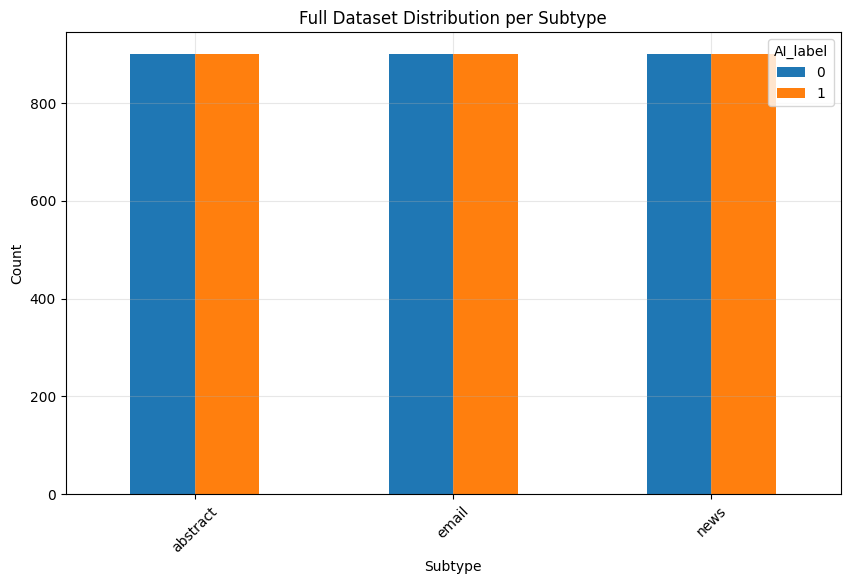

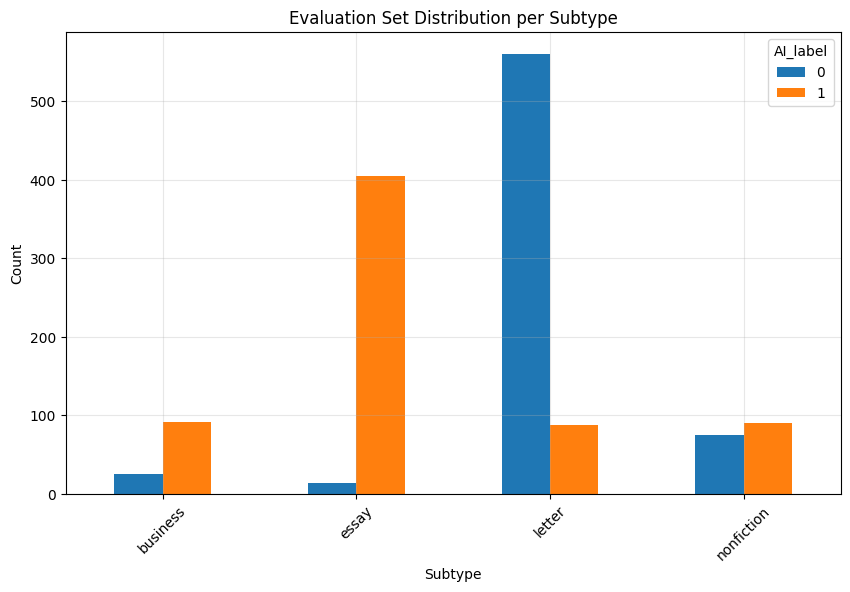

In [ ]:
# full dataset
df_5400_set = pd.read_csv("./dataset/formal_set_5400.csv")
subtype_counts = df_5400_set.groupby("sub-type")["AI_label"].value_counts().unstack(fill_value=0)

# visuals (for report)
subtype_counts.plot(kind="bar", figsize=(10,6))
plt.title("Full Dataset Distribution per Subtype")
plt.xlabel("Subtype")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()

# evaluation set
df_eval_set = pd.read_csv("./dataset/formal_val_1350.csv")
subtype_counts = df_eval_set.groupby("sub-type")["AI_label"].value_counts().unstack(fill_value=0)

# visuals (for report)
subtype_counts.plot(kind="bar", figsize=(10,6))
plt.title("Evaluation Set Distribution per Subtype")
plt.xlabel("Subtype")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.show()


## **70/15/15 Split**

Stratified by AI_label and sub-type to ensure balanced distribution in splits

In [ ]:
df = pd.read_csv("./dataset/formal_set_5400.csv")

df["strat"] = df["sub-type"].astype(str) + "_" + df["AI_label"].astype(str)

# 70% train, 30% temp (for val/test)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["strat"],
    random_state=97
)

# 15% val, 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["strat"],
    random_state=97
)

print("Train set size:", len(train_df))
print("Val set size:", len(val_df))
print("Test set size:", len(test_df))


Train set size: 3780
Val set size: 810
Test set size: 810


In [ ]:
# distributions by subtype
print("\nTrain distribution:\n", train_df.groupby(["sub-type","AI_label"]).size())
print("\nVal distribution:\n", val_df.groupby(["sub-type","AI_label"]).size())
print("\nTest distribution:\n", test_df.groupby(["sub-type","AI_label"]).size())


Train distribution:
 sub-type  AI_label
abstract  0           630
          1           630
email     0           630
          1           630
news      0           630
          1           630
dtype: int64

Val distribution:
 sub-type  AI_label
abstract  0           135
          1           135
email     0           135
          1           135
news      0           135
          1           135
dtype: int64

Test distribution:
 sub-type  AI_label
abstract  0           135
          1           135
email     0           135
          1           135
news      0           135
          1           135
dtype: int64


In [ ]:
# turn into HF dataset object
train_dataset = Dataset.from_pandas(train_df)
val_dataset   = Dataset.from_pandas(val_df)
test_dataset  = Dataset.from_pandas(test_df)

# compile all 3 splits into one dataset
formal_dataset = DatasetDict({
    "train": train_dataset,
    "val": val_dataset,
    "test": test_dataset
})

print(formal_dataset)


DatasetDict({
    train: Dataset({
        features: ['sample_text', 'sub-type', 'AI_label', 'strat', '__index_level_0__'],
        num_rows: 3780
    })
    val: Dataset({
        features: ['sample_text', 'sub-type', 'AI_label', 'strat', '__index_level_0__'],
        num_rows: 810
    })
    test: Dataset({
        features: ['sample_text', 'sub-type', 'AI_label', 'strat', '__index_level_0__'],
        num_rows: 810
    })
})


# **Fine-Tuning Prep**

## **Tokenization**

In [12]:
# Load tokenizer needed by the base model

model = "microsoft/deberta-v3-small"
tokenizer = AutoTokenizer.from_pretrained(model, use_fast=True)

tokenizer

DebertaV2Tokenizer(name_or_path='microsoft/deberta-v3-small', vocab_size=128000, model_max_length=1000000000000000019884624838656, padding_side='right', truncation_side='right', special_tokens={'bos_token': '[CLS]', 'eos_token': '[SEP]', 'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	1: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	2: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	3: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	128000: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
})

**Note: **DeBERTa V3 uses SentencePiece tokenization instead of Standard BPE and Unigram, which tokenizes raw characters (rather than getting treated like a boundary to help create words) >>> token count != word count.

In [13]:
def tokenize(example):
  tokenized = tokenizer(example["sample_text"], truncation=True, padding="max_length", max_length=350) # 512 is the max, though the dataset should be safe enough from cleaning
  tokenized["labels"] = example["AI_label"]
  return tokenized

In [ ]:
tokenized_formal_dataset = formal_dataset.map(tokenize, batched=True, remove_columns=['sample_text', 'sub-type', 'AI_label', 'strat', '__index_level_0__'])
tokenized_formal_dataset

Map:   0%|          | 0/3780 [00:00<?, ? examples/s]

Map:   0%|          | 0/810 [00:00<?, ? examples/s]

Map:   0%|          | 0/810 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 3780
    })
    val: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 810
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 810
    })
})

## **Metrics**

### **Functions Setup** (compute_metrics)

In [16]:
# updated ver.

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    # accuracy
    accuracy = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]

    # p, r, f1 (macro + weighted)
    precision, recall, f1_macro, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    _, _, f1_weighted, _ = precision_recall_fscore_support(
        labels, preds, average="weighted", zero_division=0
    )

    # roc, auc
    try:
        auc = roc_auc_score(labels, logits[:,1])
    except ValueError:
        auc = float("nan")

    return {
        "accuracy": accuracy,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "precision_macro": precision,
        "recall_macro": recall,
        "auc": auc,
    }

### **Metric Graphs**

Fine-tuning Results

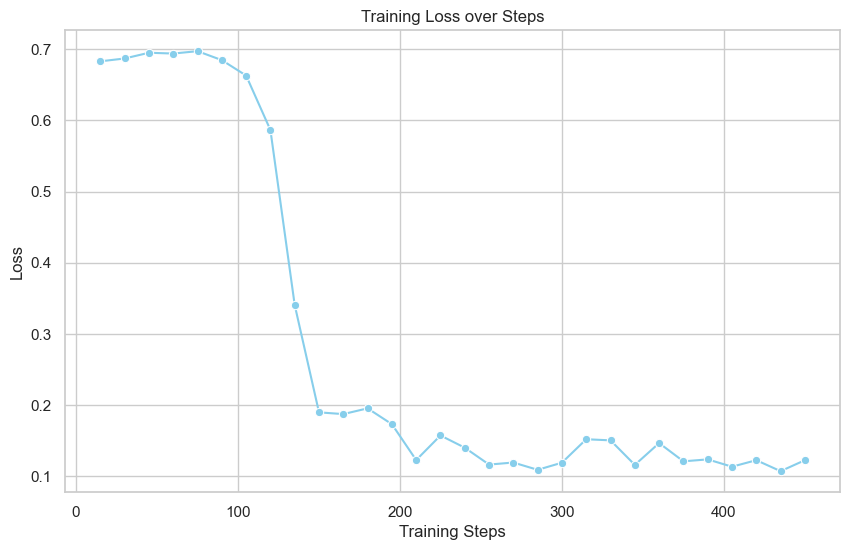

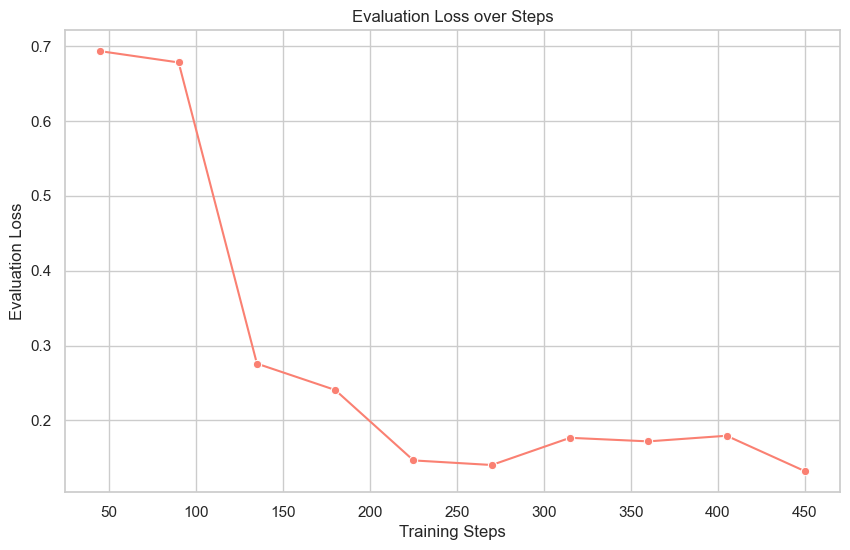

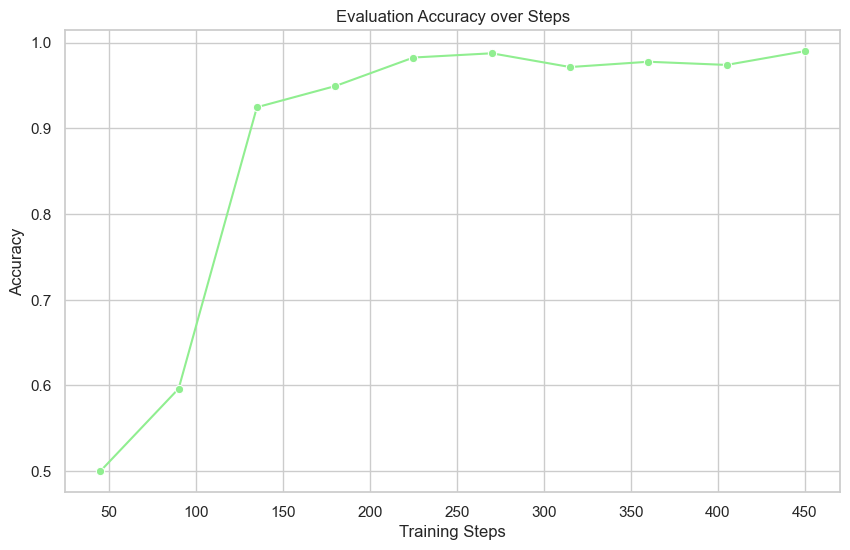

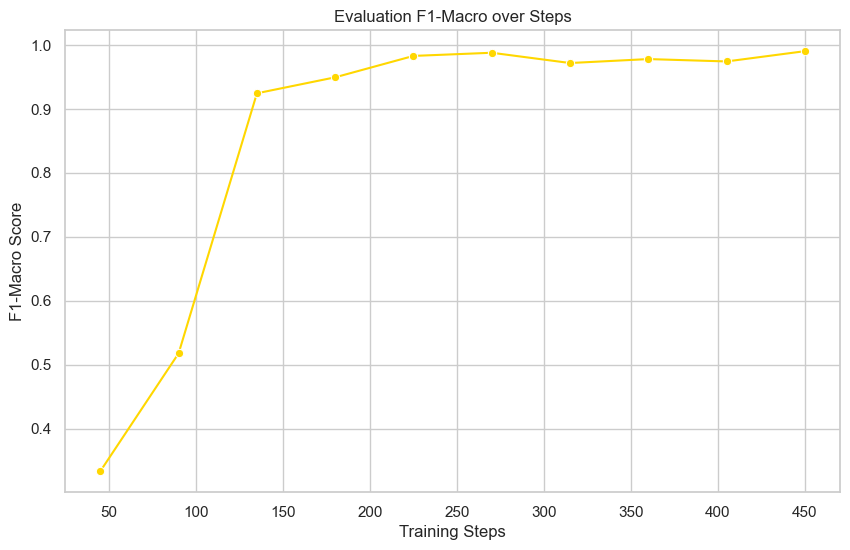

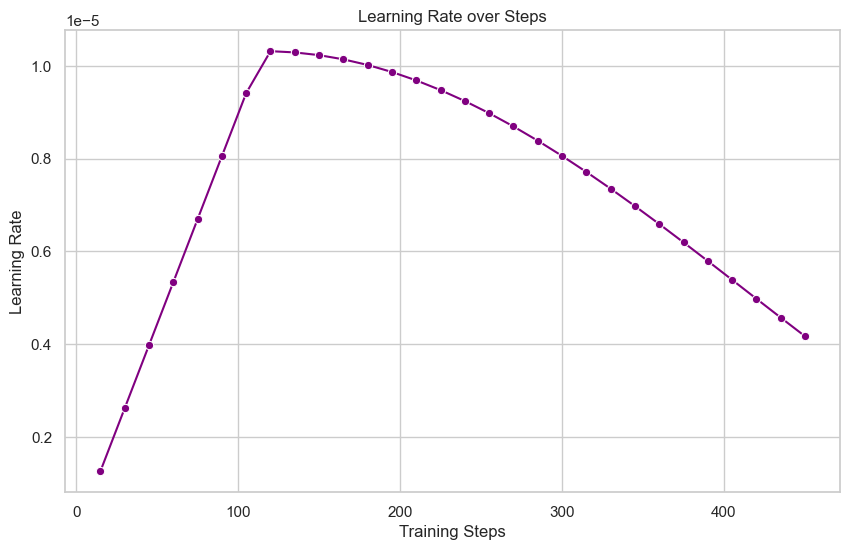

In [19]:
# metric charts from logged steps in "best model" checkpoints

output_dir = './finetune_metrics_informal'
os.makedirs(output_dir, exist_ok=True)

trainer_state_path = "./runs/deberta_v3_final_informal_2/checkpoint-450/trainer_state.json"
with open(trainer_state_path, 'r', encoding='utf-8') as file:
    trainer_state = json.load(file)

log_history = trainer_state.get('log_history', [])

# training vs. val steps
train_logs = [log for log in log_history if 'loss' in log and 'eval_loss' not in log]
eval_logs = [log for log in log_history if 'eval_loss' in log]

# extract training metrics
train_steps = [log['step'] for log in train_logs]
train_loss = [log['loss'] for log in train_logs]
train_learning_rate = [log['learning_rate'] for log in train_logs]

# extract evaluation metrics
eval_steps = [log['step'] for log in eval_logs]
eval_loss = [log['eval_loss'] for log in eval_logs]
eval_accuracy = [log['eval_accuracy'] for log in eval_logs]
eval_f1_macro = [log['eval_f1_macro'] for log in eval_logs]

sns.set_theme(style="whitegrid")

# train loss
plt.figure(figsize=(10, 6))
sns.lineplot(x=train_steps, y=train_loss, marker='o', color='skyblue')
plt.title('Training Loss over Steps')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'training_loss.png'))
plt.show()

# eval loss
plt.figure(figsize=(10, 6))
sns.lineplot(x=eval_steps, y=eval_loss, marker='o', color='salmon')
plt.title('Evaluation Loss over Steps')
plt.xlabel('Training Steps')
plt.ylabel('Evaluation Loss')
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'eval_loss.png'))
plt.show()

# eval acc
plt.figure(figsize=(10, 6))
sns.lineplot(x=eval_steps, y=eval_accuracy, marker='o', color='lightgreen')
plt.title('Evaluation Accuracy over Steps')
plt.xlabel('Training Steps')
plt.ylabel('Accuracy')
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'eval_accuracy.png'))
plt.show()

# eval F1 (macro)
plt.figure(figsize=(10, 6))
sns.lineplot(x=eval_steps, y=eval_f1_macro, marker='o', color='gold')
plt.title('Evaluation F1-Macro over Steps')
plt.xlabel('Training Steps')
plt.ylabel('F1-Macro Score')
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'eval_f1_macro.png'))
plt.show()

# plot learning rate
plt.figure(figsize=(10, 6))
sns.lineplot(x=train_steps, y=train_learning_rate, marker='o', color='purple')
plt.title('Learning Rate over Steps')
plt.xlabel('Training Steps')
plt.ylabel('Learning Rate')
plt.grid(True)
plt.savefig(os.path.join(output_dir, 'learning_rate.png'))
plt.show()

External Evaluation Results

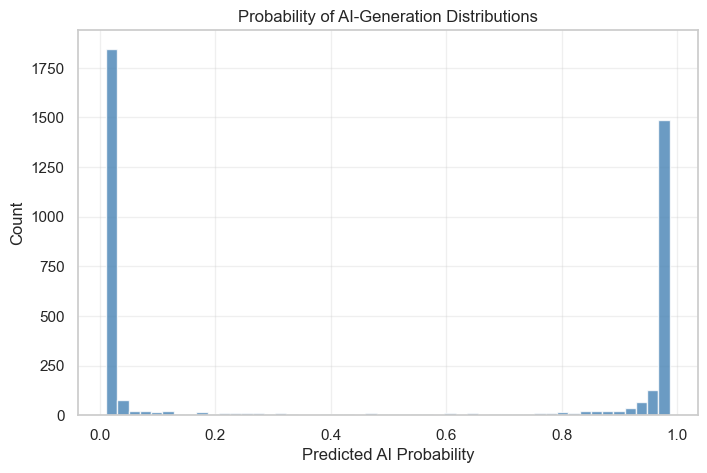

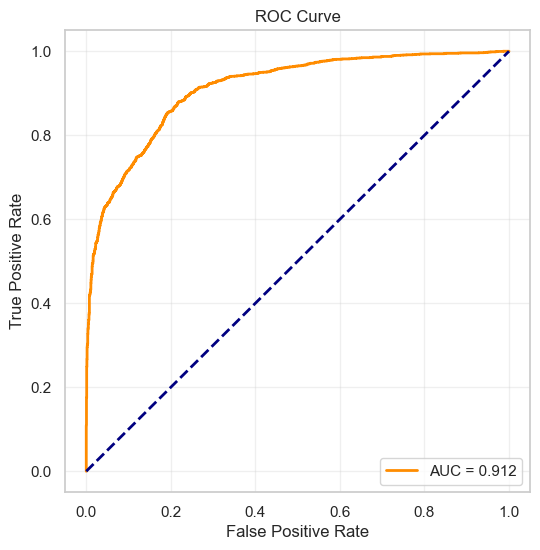

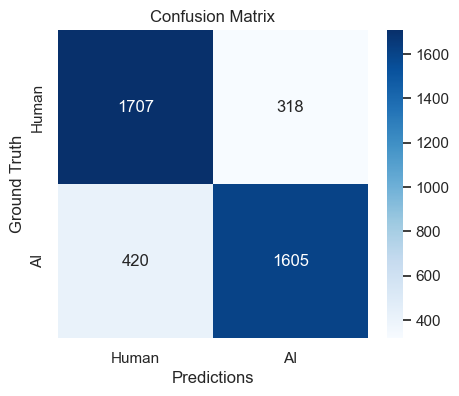

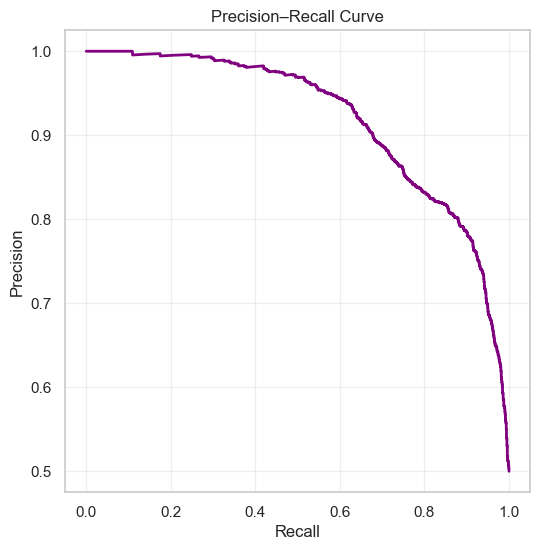

In [80]:
from sklearn.metrics import auc as sk_auc, roc_curve

output_dir = './eval_metrics_expanded'
os.makedirs(output_dir, exist_ok=True)

# AI scores
plt.figure(figsize=(8,5))
plt.hist(prob_ai, bins=50, color='steelblue', alpha=0.8)
plt.title("Probability of AI-Generation Distributions")
plt.xlabel("Predicted AI Probability")
plt.ylabel("Count")
plt.grid(alpha=0.3)
plt.savefig(os.path.join(output_dir, 'external_ai_probs.png'))
plt.show()

#roc-auc
fpr, tpr, _ = roc_curve(labels, prob_ai)
roc_auc = roc_auc_score(labels, prob_ai)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig(os.path.join(output_dir, 'external_roc_auc.png'))
plt.show()

# confusion matrix
cm = confusion_matrix(labels, predicted_classes)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Human", "AI"],
            yticklabels=["Human", "AI"])
plt.xlabel("Predictions")
plt.ylabel("Ground Truth")
plt.title("Confusion Matrix")
plt.savefig(os.path.join(output_dir, 'external_confusion_matrix.png'))
plt.show()

# p-r
precision, recall, _ = precision_recall_curve(labels, prob_ai)

plt.figure(figsize=(6,6))
plt.plot(recall, precision, lw=2, color='purple')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve")
plt.grid(alpha=0.3)
plt.savefig(os.path.join(output_dir, 'external_pr.png'))
plt.show()


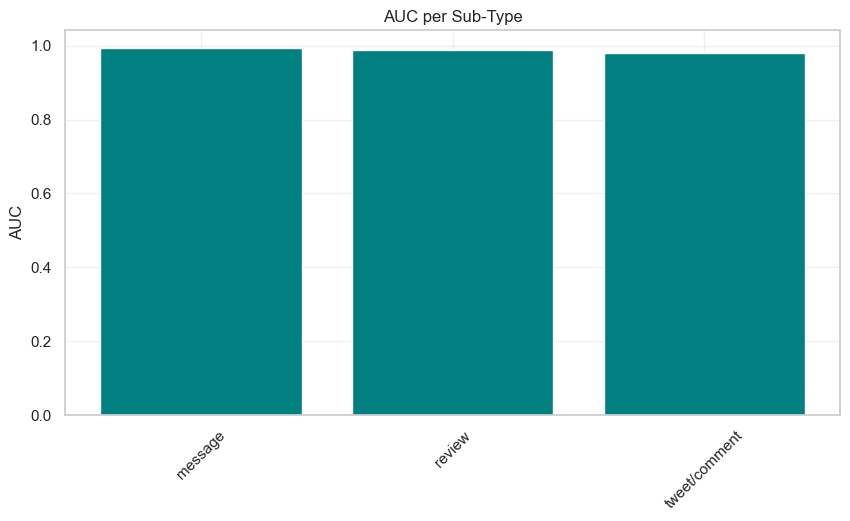

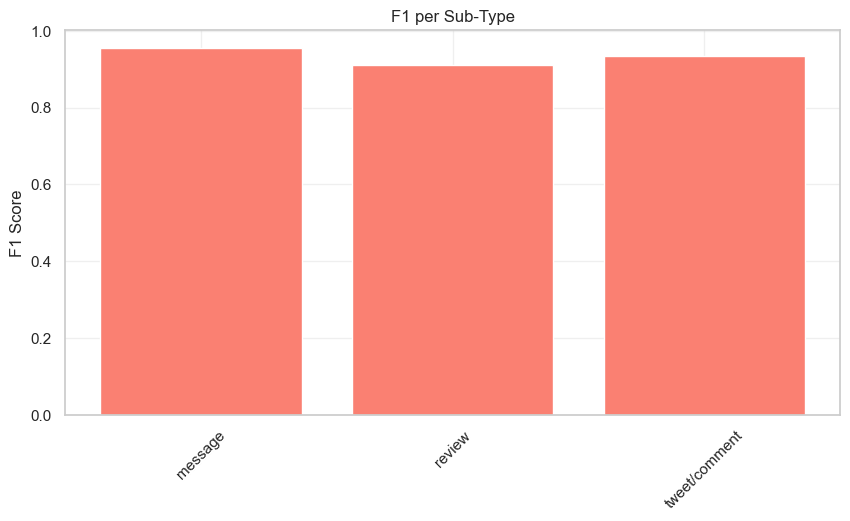

In [43]:
df_eval = pd.DataFrame({
    "label": labels,
    "pred": predicted_classes,
    "prob_ai": prob_ai,
    "sub-type": informal_external_eval_df["sub-type"]
})

subtype_scores = []

for subtype, g in df_eval.groupby("sub-type"):
    if len(g) < 10:
        continue
    auc_score = roc_auc_score(g["label"], g["prob_ai"])
    f1 = f1_score(g["label"], g["pred"])
    subtype_scores.append((subtype, auc_score, f1))

sub_df = pd.DataFrame(subtype_scores, columns=["sub-type", "auc", "f1"])

plt.figure(figsize=(10,5))
plt.bar(sub_df["sub-type"], sub_df["auc"], color='teal')
plt.xticks(rotation=45)
plt.ylabel("AUC")
plt.title("AUC per Sub-Type")
plt.grid(alpha=0.3)
plt.show()

plt.figure(figsize=(10,5))
plt.bar(sub_df["sub-type"], sub_df["f1"], color='salmon')
plt.xticks(rotation=45)
plt.ylabel("F1 Score")
plt.title("F1 per Sub-Type")
plt.grid(alpha=0.3)
plt.show()


## **Training Config**

In [17]:
model = AutoModelForSequenceClassification.from_pretrained(
    "microsoft/deberta-v3-small",
    num_labels=2,
    id2label={0: "Human-Written", 1: "AI-Generated"},
    label2id={"Human-Written": 0, "AI-Generated": 1},
    dtype=torch.float32
)

# for tensorboard
os.environ["TENSORBOARD_LOGGING_DIR"] = "./logs/final_informal_2"

final_training_args = TrainingArguments(
    seed=42,
    output_dir="./runs/deberta_v3_final_informal_2",
    report_to = "tensorboard",

    # jeffrey's setup
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=1.0317e-05,
    weight_decay=0.02586,
    warmup_steps=114,
    label_smoothing_factor=0.04114,

    lr_scheduler_type="cosine",
    optim="adamw_torch_fused" if torch.cuda.is_available() else "adamw_torch",
    adam_epsilon=1e-6,
    max_grad_norm=0.5,

    fp16=False,
    bf16=torch.cuda.is_bf16_supported(),

    eval_strategy="steps",
    eval_steps=45,
    save_strategy="steps",
    save_steps=45,
    save_total_limit=1,
    logging_steps=15,

    metric_for_best_model="accuracy",
    greater_is_better=True,
    load_best_model_at_end=True,
)

trainer = Trainer(
    model=model,
    args=final_training_args,
    train_dataset=tokenized_informal_dataset["train"],
    eval_dataset=tokenized_informal_dataset["val"],
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)]
)

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.weight                       | MISSING    | 
classifie

# **Fine-Tuning an AI-Text Detector**

## **Tensorboard**
For live viewing and comparing train/eval metrics + graphs

**Local:**

Not sure on Google runtime, but locally, it times out in the notebook for me so I don't recommend running it here.

- In command line/terminal, go to your working directory
- **tensorboard --logdir=./logs --port=6006**
- Access localhost in browser


### **Prelim Settings Rerun**

To retrieve proper metrics (tensorboard bug) and save run (lost logs to crash).
- Note: Specifically BEFORE dtype fix, so collapsing results are expected.

In [ ]:
checkpoint = "microsoft/deberta-v3-small"
num_labels = 2
id2label = {0:"Human-Written", 1:"AI-Generated"}
label2id = {"Human-Written":0, "AI-Generated":1}
model = AutoModelForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    dtype=torch.float32 # change
)

# for tensorboard
os.environ["TENSORBOARD_LOGGING_DIR"] = "./logs"

training_args = TrainingArguments(
    seed=42,
    output_dir="./runs/deberta_v3_small_dtype",
    logging_dir="./logs/dtype",
    logging_steps=20,

    report_to = "tensorboard",

    num_train_epochs=4,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.05,

    lr_scheduler_type="linear",
    warmup_steps=50,

    eval_strategy="steps",
    eval_steps = 85,
    save_strategy="steps",
    save_steps = 85,
    save_total_limit = 2,

    max_grad_norm=1.0,
    fp16=True,

    metric_for_best_model="eval_loss",
    greater_is_better=False,
    load_best_model_at_end=True,

)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset['train'],
    eval_dataset=tokenized_dataset['val'],
    compute_metrics=compute_metrics
)

Loading weights:   0%|          | 0/102 [00:00<?, ?it/s]

[transformers] DebertaV2ForSequenceClassification LOAD REPORT from: microsoft/deberta-v3-small
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
classifier.bias                         | MISSING    | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifie

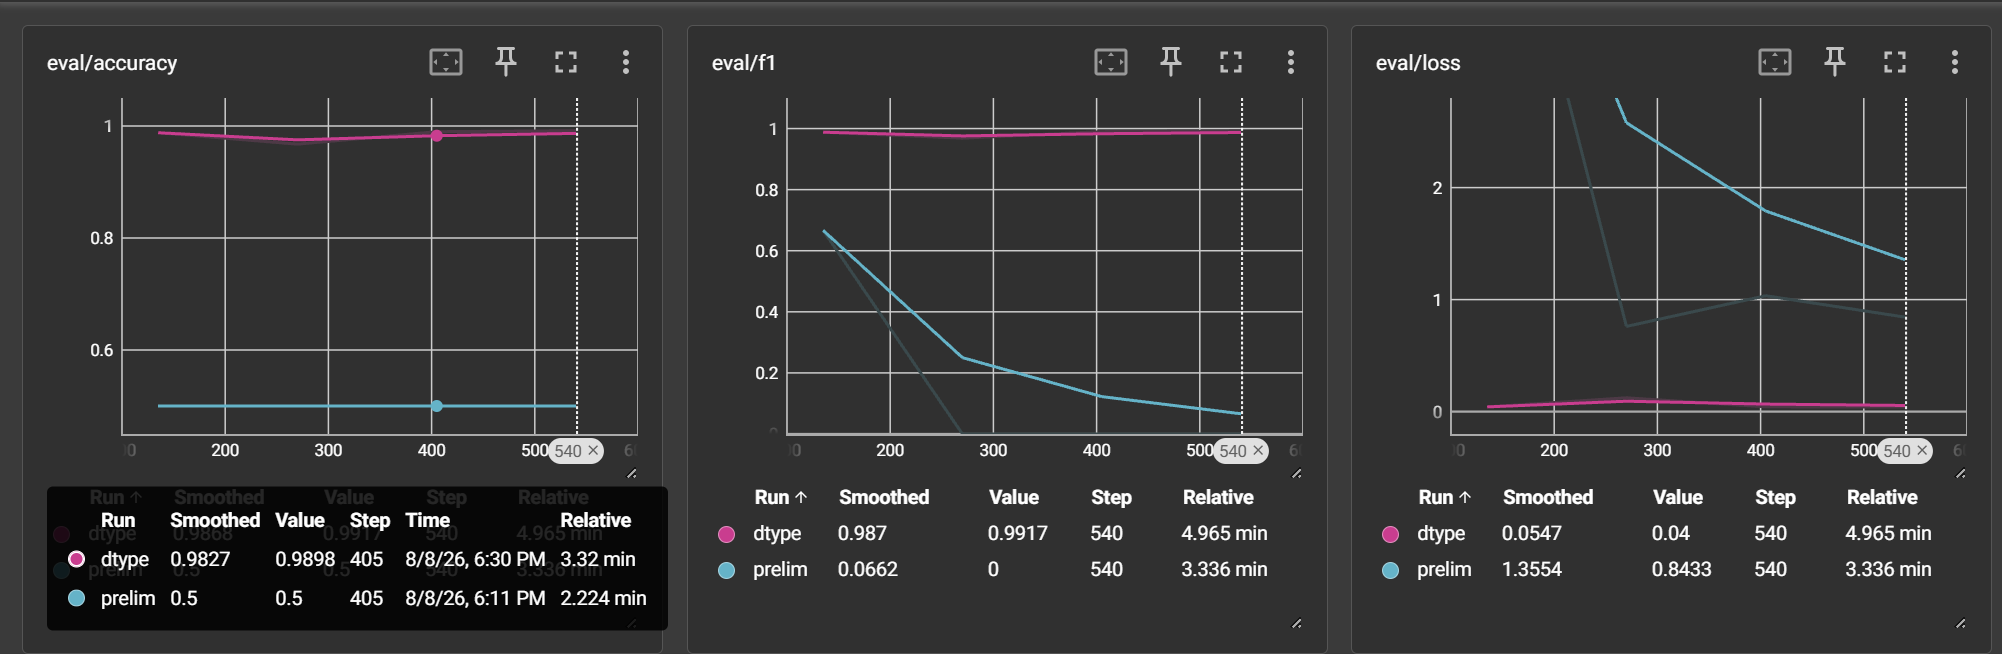

### Dataset Split

70/15/15 Split: Fine-tune using train and val splits, evaluate on test after.

In [ ]:
trainer.train()

# Save final tuned model weights AND TOKENIZER <-- so important, so SO VERY IMPORTANT.
trainer.save_model("./models/deberta_v3_final")
tokenizer.save_pretrained("./models/deberta_v3_final")

Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro,Auc
45,0.689851,0.692138,0.500000,0.333333,0.333333,0.250000,0.500000,0.773449
90,0.675374,0.657636,0.502469,0.338797,0.338797,0.750619,0.502469,0.861195
135,0.364160,0.285761,0.919753,0.919325,0.919325,0.928854,0.919753,0.989852
180,0.204834,0.214337,0.941975,0.941811,0.941811,0.947014,0.941975,0.992458
225,0.198075,0.169926,0.972840,0.972829,0.972829,0.973579,0.972840,0.992571
270,0.147694,0.137923,0.983951,0.983951,0.983951,0.983954,0.983951,0.994044
315,0.133461,0.162820,0.976543,0.976537,0.976537,0.977035,0.976543,0.996607
360,0.110946,0.146105,0.985185,0.985184,0.985184,0.985375,0.985185,0.994781
405,0.159884,0.135694,0.986420,0.986419,0.986419,0.986494,0.986420,0.995111
450,0.114730,0.149211,0.983951,0.983949,0.983949,0.984190,0.983951,0.996635


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./models/deberta_v3_final\\tokenizer_config.json',
 './models/deberta_v3_final\\tokenizer.json')

# **Evaluation/Testing**

In [ ]:
import hashlib

def hash_text(s):
    return hashlib.md5(s.encode('utf-8')).hexdigest()

train_hashes = set(train_df['sample_text'].apply(hash_text).tolist())
test_df['text_hash'] = test_df['sample_text'].apply(hash_text)

dups_mask = test_df['text_hash'].isin(train_hashes)
print("Duplicates in test that appear in train:", dups_mask.sum())

print(test_df[dups_mask][['sample_text']].head(10).to_dict(orient='records'))

# if needed:
clean_test_df = test_df[~dups_mask].reset_index(drop=True)
print("Clean test size:", len(clean_test_df))


Duplicates in test that appear in train: 0
[]
Clean test size: 810


## Test 1: Test Set Evaluation
Unseen 15% split of original 5400 dataset; interpolation test



In [ ]:
tokenized_formal_dataset

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 3780
    })
    val: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 810
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 810
    })
})

In [45]:
# load best model AND TOKENIZER
checkpoint_dir = "./models/deberta_v3_final"
tokenizer = AutoTokenizer.from_pretrained(checkpoint_dir)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint_dir, dtype=torch.float32)
model.eval()

# kc sanity check
formal_df = pd.read_csv("./dataset/formal_set_5400.csv")
test_text = formal_df["sample_text"].iloc[0]
print("loaded tokenizing sample:", tokenizer(test_text)["input_ids"][:15])

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

loaded tokenizing sample: [1, 13996, 261, 345, 281, 1005, 264, 333, 291, 260, 27154, 301, 3426, 1305, 1827]


In [ ]:
def tokenize(example):
    tokenized = tokenizer(example["sample_text"], truncation=True, padding="max_length",max_length=350)
    tokenized["labels"] = example["AI_label"]
    return tokenized

tokenized_test_set = formal_dataset['test'].map(
    tokenize,
    batched=True,
    remove_columns=['sample_text', 'sub-type', 'AI_label', 'strat', '__index_level_0__']
)

eval_args = TrainingArguments(output_dir="./tmp_eval", per_device_eval_batch_size=16, report_to="none")
eval_trainer = Trainer(model=model, args=eval_args)

preds_output = eval_trainer.predict(tokenized_test_set)
logits = preds_output.predictions
labels = preds_output.label_ids
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
prob_ai = probs[:, 1]
predicted_classes = np.argmax(logits, axis=-1)

print("True label distribution:", Counter(labels.tolist()))
print("Predicted label distribution:", Counter(predicted_classes.tolist()))
print("AUC:", roc_auc_score(labels, prob_ai))
print("F1:", f1_score(labels, predicted_classes))
print("Confusion matrix:\n", confusion_matrix(labels, predicted_classes))

Map:   0%|          | 0/810 [00:00<?, ? examples/s]

True label distribution: Counter({1: 405, 0: 405})
Predicted label distribution: Counter({1: 408, 0: 402})
AUC: 0.9998292943148911
F1: 0.993849938499385
Confusion matrix:
 [[401   4]
 [  1 404]]


## Test 2: External Evaluation Set
Cross-domain generalization test

Formal Set: 1350 samples, 4 new genres, unrepresented models

In [44]:
external_eval_df = pd.read_csv("./dataset/formal_val_1350.csv")
external_eval_set = Dataset.from_pandas(external_eval_df)

tokenized_external_set = external_eval_set.map(
    tokenize,
    batched=True,
    remove_columns=['sample_text', 'sub-type', 'AI_label']
)


Map:   0%|          | 0/1350 [00:00<?, ? examples/s]

In [46]:
tokenized_external_set

Dataset({
    features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
    num_rows: 1350
})

In [48]:
eval_args = TrainingArguments(output_dir="./tmp_eval", per_device_eval_batch_size=16, report_to="none")
eval_trainer = Trainer(model=model, args=eval_args)

preds_output = eval_trainer.predict(tokenized_external_set)
logits = preds_output.predictions
labels = preds_output.label_ids
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
prob_ai = probs[:, 1]
predicted_classes = np.argmax(logits, axis=-1)

print("True label distribution:", Counter(labels.tolist()))
print("Predicted label distribution:", Counter(predicted_classes.tolist()))
print("AUC:", roc_auc_score(labels, prob_ai))
print("F1:", f1_score(labels, predicted_classes))
print("Confusion matrix:\n", confusion_matrix(labels, predicted_classes))

True label distribution: Counter({0: 675, 1: 675})
Predicted label distribution: Counter({1: 684, 0: 666})
AUC: 0.9992471879286693
F1: 0.9816041206769683
Confusion matrix:
 [[658  17]
 [  8 667]]


In [49]:
external_test_probs = torch.softmax(
    torch.tensor(preds_output.predictions), dim=-1
).numpy()[:, 1]

external_eval_class = np.argmax(preds_output.predictions, axis=-1)

external_eval_df = external_eval_df.reset_index(drop=True)

external_eval_df["label"] = preds_output.label_ids
external_eval_df["pred"] = predicted_classes
external_eval_df["prob_ai"] = external_eval_class

external_eval_df

,sample_text,sub-type,AI_label,label,pred,prob_ai
0,Even though lots of students like to work at h...,letter,0,0,0,0
1,Fresh air we're use to being home all day and ...,nonfiction,0,0,0,0
2,Many people believe that self-esteem comes fro...,letter,0,0,1,1
3,"Clearly, everyone should always aim high and a...",letter,0,0,1,1
4,I really think that can be really stressed for...,letter,0,0,0,0
...,...,...,...,...,...,...
1345,Cryptography is the discipline concerned with ...,nonfiction,1,1,1,1
1346,Cultural anthropology investigates the diversi...,nonfiction,1,1,1,1
1347,The solar system consists of the Sun and the g...,nonfiction,1,1,1,1
1348,Public health is defined as the organized effo...,nonfiction,1,1,1,1


### External Eval Set Metrics

In [81]:
dashboard = []

for subtype, group in external_eval_expanded_df.groupby('sub-type'):
    report = classification_report(
        group['AI_label'], group['pred'], digits=4, output_dict=True
    )

    try:
        auc = roc_auc_score(group['AI_label'], group['prob_ai'])
    except ValueError:
        auc = None

    dashboard.append({
        "subtype": subtype,
        "accuracy": report["accuracy"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "auc": auc,
        "report": report
    })


KeyError: 'pred'

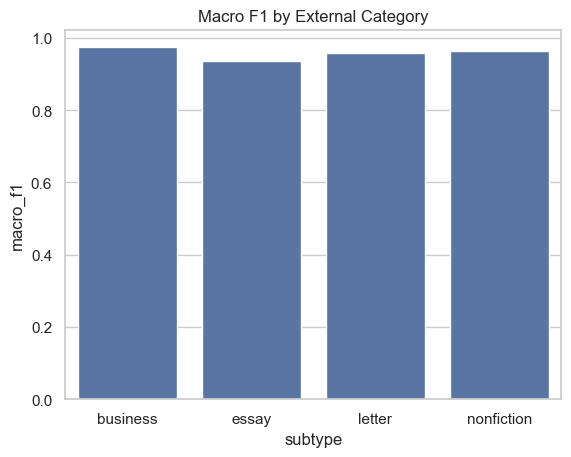

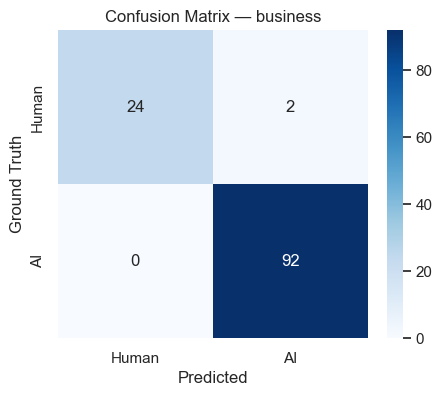

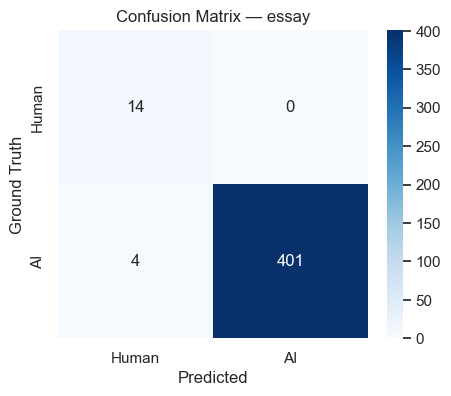

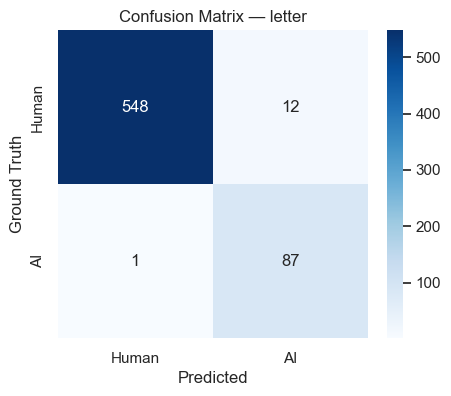

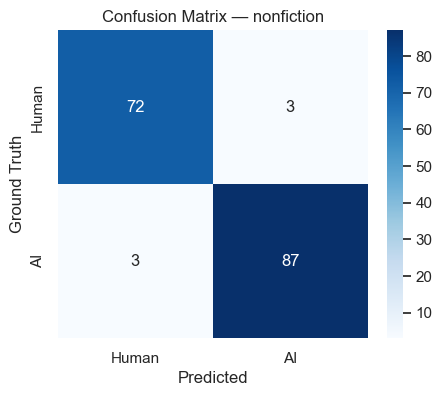

In [53]:
output_dir = './eval_metrics_newest'

df_dashboard = pd.DataFrame(dashboard)
df_dashboard

sns.barplot(data=df_dashboard, x="subtype", y="macro_f1")
plt.title("Macro F1 by External Category")
plt.show()

for subtype, group in external_eval_df.groupby('sub-type'):
    y_true = group['AI_label']
    y_pred = group['pred']

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Human', 'AI'],
                yticklabels=['Human', 'AI'])
    plt.title(f'Confusion Matrix — {subtype}')
    plt.xlabel('Predicted')
    plt.ylabel('Ground Truth')
    plt.savefig(os.path.join(output_dir, f'{subtype}_confusion_matrix.png'))
    plt.show()


# Informal Fixed Runs for Hung & Mahla

In [8]:
informal_df = pd.read_csv("informal_samples.csv", encoding="Latin-1")

informal_df["strat"] = informal_df["sub-type"].astype(str) + "_" + informal_df["AI_label"].astype(str)

# 70% train, 30% temp (for val/test)
informal_train_df, temp_df = train_test_split(
    informal_df,
    test_size=0.30,
    stratify=informal_df["strat"],
    random_state=97
)

# 15% val, 15% test
informal_val_df, informal_test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["strat"],
    random_state=97
)

print("Train set size:", len(informal_train_df))
print("Val set size:", len(informal_val_df))
print("Test set size:", len(informal_test_df))


Train set size: 3780
Val set size: 810
Test set size: 810


In [9]:
# distributions by subtype
print("\nTrain distribution:\n", informal_train_df.groupby(["sub-type","AI_label"]).size())
print("\nVal distribution:\n", informal_val_df.groupby(["sub-type","AI_label"]).size())
print("\nTest distribution:\n", informal_test_df.groupby(["sub-type","AI_label"]).size())


Train distribution:
 sub-type       AI_label
message        0           630
               1           630
review         0           630
               1           630
tweet/comment  0           630
               1           630
dtype: int64

Val distribution:
 sub-type       AI_label
message        0           135
               1           135
review         0           135
               1           135
tweet/comment  0           135
               1           135
dtype: int64

Test distribution:
 sub-type       AI_label
message        0           135
               1           135
review         0           135
               1           135
tweet/comment  0           135
               1           135
dtype: int64


In [10]:
# turn into HF dataset object
train_dataset = Dataset.from_pandas(informal_train_df)
val_dataset   = Dataset.from_pandas(informal_val_df)
test_dataset  = Dataset.from_pandas(informal_test_df)

# compile all 3 splits into one dataset
informal_dataset = DatasetDict({
    "train": train_dataset,
    "val": val_dataset,
    "test": test_dataset
})

print(informal_dataset)

DatasetDict({
    train: Dataset({
        features: ['sample_text', 'sub-type', 'AI_label', 'strat', '__index_level_0__'],
        num_rows: 3780
    })
    val: Dataset({
        features: ['sample_text', 'sub-type', 'AI_label', 'strat', '__index_level_0__'],
        num_rows: 810
    })
    test: Dataset({
        features: ['sample_text', 'sub-type', 'AI_label', 'strat', '__index_level_0__'],
        num_rows: 810
    })
})


In [14]:
tokenized_informal_dataset = informal_dataset.map(tokenize, batched=True, remove_columns=['sample_text', 'sub-type', 'AI_label', 'strat', '__index_level_0__'])
tokenized_informal_dataset

Map:   0%|          | 0/3780 [00:00<?, ? examples/s]

Map:   0%|          | 0/810 [00:00<?, ? examples/s]

Map:   0%|          | 0/810 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 3780
    })
    val: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 810
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels'],
        num_rows: 810
    })
})

In [18]:
trainer.train()

# Save final tuned model weights AND TOKENIZER <-- so important, so SO VERY IMPORTANT.
trainer.save_model("./models/deberta_v3_final_informal_2")
tokenizer.save_pretrained("./models/deberta_v3_final_informal_2")

Step,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro,Auc
45,0.695061,0.692972,0.500000,0.333333,0.333333,0.250000,0.500000,0.722814
90,0.684692,0.677916,0.596296,0.517691,0.517691,0.776639,0.596296,0.980750
135,0.340580,0.275901,0.924691,0.924262,0.924262,0.934549,0.924691,0.987304
180,0.195371,0.240714,0.949383,0.949253,0.949253,0.954036,0.949383,0.997418
225,0.157258,0.146683,0.982716,0.982711,0.982711,0.983294,0.982716,0.999369
270,0.119234,0.140571,0.987654,0.987652,0.987652,0.987952,0.987654,0.999701
315,0.151954,0.176853,0.971605,0.971582,0.971582,0.973131,0.971605,0.998793
360,0.146549,0.172104,0.977778,0.977767,0.977767,0.978723,0.977778,0.998238
405,0.113341,0.179611,0.974074,0.974057,0.974057,0.975352,0.974074,0.997058
450,0.122505,0.132329,0.990123,0.990122,0.990122,0.990315,0.990123,0.998372


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./models/deberta_v3_final_informal_2\\tokenizer_config.json',
 './models/deberta_v3_final_informal_2\\tokenizer.json')

Test split evaluation:

In [20]:
# load best model AND TOKENIZER
checkpoint_dir = "./models/deberta_v3_final_informal_2"
tokenizer = AutoTokenizer.from_pretrained(checkpoint_dir)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint_dir, dtype=torch.float32)
model.eval()

# kc sanity check
df = pd.read_csv("informal_samples.csv", encoding="Latin-1")
test_text = df["sample_text"].iloc[0]
print("loaded tokenizing sample:", tokenizer(test_text)["input_ids"][:15])

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

loaded tokenizing sample: [1, 278, 284, 262, 410, 265, 631, 278, 284, 262, 3130, 265, 631, 2]


In [21]:
def tokenize(example):
    tokenized = tokenizer(example["sample_text"], truncation=True, padding="max_length",max_length=350)
    tokenized["labels"] = example["AI_label"]
    return tokenized

tokenized_test_set = informal_dataset['test'].map(
    tokenize,
    batched=True,
    remove_columns=['sample_text', 'sub-type', 'AI_label', 'strat', '__index_level_0__']
)

eval_args = TrainingArguments(output_dir="./tmp_eval", per_device_eval_batch_size=16, report_to="none")
eval_trainer = Trainer(model=model, args=eval_args)

preds_output = eval_trainer.predict(tokenized_test_set)
logits = preds_output.predictions
labels = preds_output.label_ids
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
prob_ai = probs[:, 1]
predicted_classes = np.argmax(logits, axis=-1)

print("True label distribution:", Counter(labels.tolist()))
print("Predicted label distribution:", Counter(predicted_classes.tolist()))
print("AUC:", roc_auc_score(labels, prob_ai))
print("F1:", f1_score(labels, predicted_classes))
print("Confusion matrix:\n", confusion_matrix(labels, predicted_classes))

Map:   0%|          | 0/810 [00:00<?, ? examples/s]

True label distribution: Counter({1: 405, 0: 405})
Predicted label distribution: Counter({1: 421, 0: 389})
AUC: 0.9976406035665295
F1: 0.9782082324455206
Confusion matrix:
 [[388  17]
 [  1 404]]


External set evaluation:

In [28]:
informal_external_eval_df = pd.read_csv("outsideval_informal_samples.csv", encoding="Latin-1")
informal_external_eval_set = Dataset.from_pandas(informal_external_eval_df)

tokenized_informal_external_set = informal_external_eval_set.map(
    tokenize,
    batched=True,
    remove_columns=['sample_text', 'sub-type', 'AI_label']
)


Map:   0%|          | 0/1350 [00:00<?, ? examples/s]

In [29]:
preds_output = eval_trainer.predict(tokenized_informal_external_set)
logits = preds_output.predictions
labels = preds_output.label_ids
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
prob_ai = probs[:, 1]
predicted_classes = np.argmax(logits, axis=-1)

print("True label distribution:", Counter(labels.tolist()))
print("Predicted label distribution:", Counter(predicted_classes.tolist()))
print("AUC:", roc_auc_score(labels, prob_ai))
print("F1:", f1_score(labels, predicted_classes))
print("Confusion matrix:\n", confusion_matrix(labels, predicted_classes))

True label distribution: Counter({0: 675, 1: 675})
Predicted label distribution: Counter({0: 723, 1: 627})
AUC: 0.9855582990397805
F1: 0.9339477726574501
Confusion matrix:
 [[656  19]
 [ 67 608]]


External Set Metrics

In [30]:
informal_external_test_probs = torch.softmax(
    torch.tensor(preds_output.predictions), dim=-1
).numpy()[:, 1]

informal_external_eval_class = np.argmax(preds_output.predictions, axis=-1)

informal_external_eval_df = informal_external_eval_df.reset_index(drop=True)

informal_external_eval_df["label"] = preds_output.label_ids
informal_external_eval_df["pred"] = predicted_classes
informal_external_eval_df["prob_ai"] = informal_external_eval_class

informal_external_eval_df

,sample_text,sub-type,AI_label,label,pred,prob_ai
0,im guessing this may start causing us problems...,message,0,0,0,0
1,not getting anywhere with this damn job huntin...,message,0,0,0,0
2,"K give me a sec, breaking a &lt;#&gt; at cstore",message,0,0,0,0
3,if u dnt wnt to tel its fyn wid me,message,0,0,0,0
4,Yup... From what i remb... I think should be c...,message,0,0,0,0
...,...,...,...,...,...,...
1345,"This train is late, overcrowded, and smells li...",tweet/comment,1,1,1,1
1346,My food order had everything wrong. I didnÕt a...,tweet/comment,1,1,1,1
1347,This productÕs instructions are in hieroglyphi...,tweet/comment,1,1,1,1
1348,That sports teamÕs performance this season is ...,tweet/comment,1,1,1,1


In [31]:
dashboard = []

for subtype, group in informal_external_eval_df.groupby('sub-type'):
    report = classification_report(
        group['AI_label'], group['pred'], digits=4, output_dict=True
    )

    try:
        auc = roc_auc_score(group['AI_label'], group['prob_ai'])
    except ValueError:
        auc = None

    dashboard.append({
        "subtype": subtype,
        "accuracy": report["accuracy"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "auc": auc,
        "report": report
    })


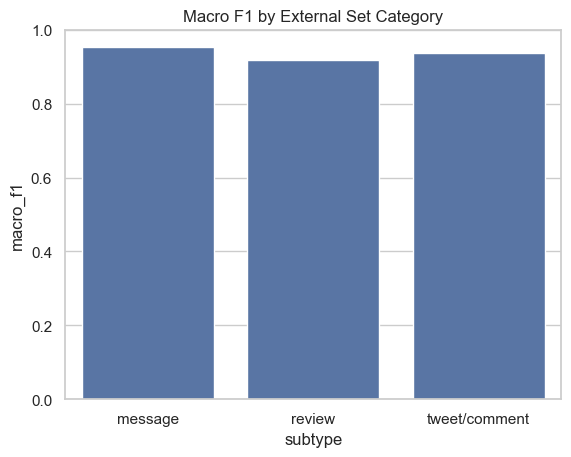

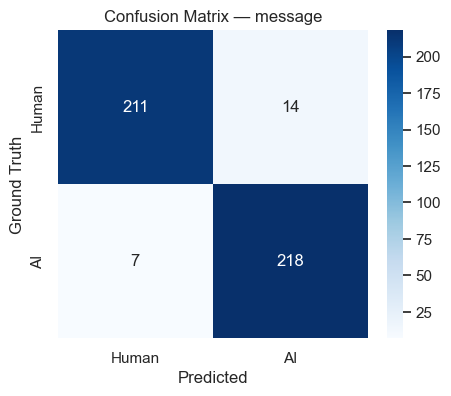

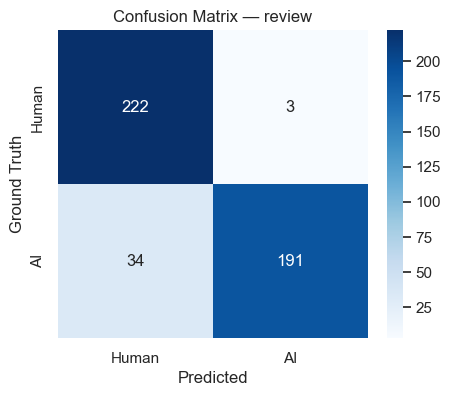

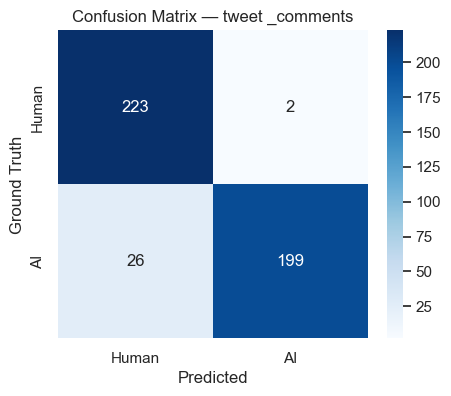

In [41]:
output_dir = './eval_metrics_informal_external'

df_dashboard = pd.DataFrame(dashboard)
df_dashboard

sns.barplot(data=df_dashboard, x="subtype", y="macro_f1")
plt.title("Macro F1 by External Set Category")
plt.savefig(os.path.join(output_dir, 'external_macro_f1.png'))
plt.show()

for subtype, group in informal_external_eval_df.groupby('sub-type'):
    y_true = group['AI_label']
    y_pred = group['pred']

    cm = confusion_matrix(y_true, y_pred)

    if subtype == "tweet/comment":
      subtype_str = subtype.replace("/comment", " _comments")
    else:
      subtype_str = subtype

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Human', 'AI'],
                yticklabels=['Human', 'AI'])
    plt.title(f'Confusion Matrix — {subtype_str}')
    plt.xlabel('Predicted')
    plt.ylabel('Ground Truth')
    plt.savefig(os.path.join(output_dir, f'{subtype_str}_confusion_matrix.png'))
    plt.show()

# Bonus: Expanded Formal Set

When our leading hypothesis to DeBERTa's poor performance was our dataset and its insufficient coverage and potential stylistic imbalance, I quickly extracted samples from the **M4 ("Multi-generator, Multi-domain, and Multi-lingual Black-Box Machine-Generated Text Detection)** Dataset to create an extended version of the formal dataset (with updated metadata). The counts for each are balanced as I selected folders with both "human_text" and "machine_text" to extract from each sample.

I did not get to test it properly as more diverse coverage didn't help our results at the time (now knowing the real issue, of course it didn't).

Now that the real issue has been diagnosed and fixed, I'll extract the M4 expansion samples from the 8100 sample compilation, and added them to the external source evaluation set (formal ver.) to see how the final formal model performs on a huge amount of test data.

Because... why not? I'm still too skeptical of how good it got once it finally had all its functioning components and would like to see if I can find a place where it struggles.

In [ ]:
informal_df["strat"] = informal_df["sub-type"].astype(str) + "_" + informal_df["AI_label"].astype(str)

In [71]:
formal_expanded_df = pd.read_csv("./dataset/full_set_metadata_expanded.csv")
print(formal_expanded_df['subtype'].value_counts())
formal_expanded_df

subtype
email            1800
news             1800
abstract         1800
scholar           900
instructional     900
encyclopedia      900
Name: count, dtype: int64


,sample_id,sample_text,ai_label,subtype,source,filename
0,arxiv_scholarly_1,We address the problem of constructing high-...,0,scholar,arxiv,arxiv_scholarly_mixed_900.csv
1,arxiv_scholarly_2,We propose a pairing-based method for coolin...,0,scholar,arxiv,arxiv_scholarly_mixed_900.csv
2,arxiv_scholarly_3,Energetic feedback processes during the form...,0,scholar,arxiv,arxiv_scholarly_mixed_900.csv
3,arxiv_scholarly_4,Using a semi-analytical model for galaxy for...,0,scholar,arxiv,arxiv_scholarly_mixed_900.csv
4,arxiv_scholarly_5,Numerical simulations suggest that active ga...,0,scholar,arxiv,arxiv_scholarly_mixed_900.csv
...,...,...,...,...,...,...
8095,dolly_v2_encyclopedia_446,"Helio Vera (born Helio Andrade; January 1, 195...",1,encyclopedia,dolly_v2,wikipedia_encyclopedia_mixed_900.csv
8096,dolly_v2_encyclopedia_447,The Allied Standards Avionics Architecture Cou...,1,encyclopedia,dolly_v2,wikipedia_encyclopedia_mixed_900.csv
8097,dolly_v2_encyclopedia_448,Valet Girls is a 2019 Indian Hindi-language bi...,1,encyclopedia,dolly_v2,wikipedia_encyclopedia_mixed_900.csv
8098,dolly_v2_encyclopedia_449,Benalto was an Italian record label founded in...,1,encyclopedia,dolly_v2,wikipedia_encyclopedia_mixed_900.csv


In [72]:
m4_subtypes = ["scholar", "instructional", "encyclopedia"]
m4_samples = pd.DataFrame()

for sub in m4_subtypes:
  subtype_df = formal_expanded_df[formal_expanded_df["subtype"] == sub]
  m4_samples = pd.concat([m4_samples, subtype_df])

m4_samples

,sample_id,sample_text,ai_label,subtype,source,filename
0,arxiv_scholarly_1,We address the problem of constructing high-...,0,scholar,arxiv,arxiv_scholarly_mixed_900.csv
1,arxiv_scholarly_2,We propose a pairing-based method for coolin...,0,scholar,arxiv,arxiv_scholarly_mixed_900.csv
2,arxiv_scholarly_3,Energetic feedback processes during the form...,0,scholar,arxiv,arxiv_scholarly_mixed_900.csv
3,arxiv_scholarly_4,Using a semi-analytical model for galaxy for...,0,scholar,arxiv,arxiv_scholarly_mixed_900.csv
4,arxiv_scholarly_5,Numerical simulations suggest that active ga...,0,scholar,arxiv,arxiv_scholarly_mixed_900.csv
...,...,...,...,...,...,...
8095,dolly_v2_encyclopedia_446,"Helio Vera (born Helio Andrade; January 1, 195...",1,encyclopedia,dolly_v2,wikipedia_encyclopedia_mixed_900.csv
8096,dolly_v2_encyclopedia_447,The Allied Standards Avionics Architecture Cou...,1,encyclopedia,dolly_v2,wikipedia_encyclopedia_mixed_900.csv
8097,dolly_v2_encyclopedia_448,Valet Girls is a 2019 Indian Hindi-language bi...,1,encyclopedia,dolly_v2,wikipedia_encyclopedia_mixed_900.csv
8098,dolly_v2_encyclopedia_449,Benalto was an Italian record label founded in...,1,encyclopedia,dolly_v2,wikipedia_encyclopedia_mixed_900.csv


In [73]:
# clean out metadata columns (initially meant for more specific stratification)
# then rename to match format of eval set before concat

m4_samples = m4_samples.drop(columns=["sample_id", "source", "filename"])
m4_samples = m4_samples.rename(columns={"subtype": "sub-type", "ai_label": "AI_label"})

external_eval_expanded_df = pd.read_csv("./dataset/formal_val_1350.csv")
external_eval_expanded_df = pd.concat([external_eval_expanded_df, m4_samples])

external_eval_expanded_df

,sample_text,sub-type,AI_label
0,Even though lots of students like to work at h...,letter,0
1,Fresh air we're use to being home all day and ...,nonfiction,0
2,Many people believe that self-esteem comes fro...,letter,0
3,"Clearly, everyone should always aim high and a...",letter,0
4,I really think that can be really stressed for...,letter,0
...,...,...,...
8095,"Helio Vera (born Helio Andrade; January 1, 195...",encyclopedia,1
8096,The Allied Standards Avionics Architecture Cou...,encyclopedia,1
8097,Valet Girls is a 2019 Indian Hindi-language bi...,encyclopedia,1
8098,Benalto was an Italian record label founded in...,encyclopedia,1


Evaluating on final DeBERTa v3 Formal Detector

In [74]:
# load best model AND TOKENIZER
checkpoint_dir = "./models/deberta_v3_final"
tokenizer = AutoTokenizer.from_pretrained(checkpoint_dir)
model = AutoModelForSequenceClassification.from_pretrained(checkpoint_dir, dtype=torch.float32)
model.eval()

# kc sanity check
test_text = external_eval_expanded_df["sample_text"].iloc[0]
print("loaded tokenizing sample:", tokenizer(test_text)["input_ids"][:15])

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

loaded tokenizing sample: [1, 1289, 651, 1738, 265, 598, 334, 264, 374, 288, 425, 261, 273, 4213, 770]


In [75]:
external_eval_expanded_set = Dataset.from_pandas(external_eval_expanded_df)
external_eval_expanded_set

Dataset({
    features: ['sample_text', 'sub-type', 'AI_label', '__index_level_0__'],
    num_rows: 4050
})

In [77]:
def tokenize(example):
    tokenized = tokenizer(example["sample_text"], truncation=True, padding="max_length",max_length=350)
    tokenized["labels"] = example["AI_label"]
    return tokenized

tokenized_expanded_eval_set = external_eval_expanded_set.map(
    tokenize,
    batched=True,
    remove_columns=['sample_text', 'sub-type', 'AI_label', '__index_level_0__']
)

eval_args = TrainingArguments(output_dir="./tmp_eval", per_device_eval_batch_size=16, report_to="none")
eval_trainer = Trainer(model=model, args=eval_args)

Map:   0%|          | 0/4050 [00:00<?, ? examples/s]

Note to self: extract a select amount of samples from the expanded samples because you just ran 2700 new samples through this poor thing. Poor computer. At least batch them or something next time?

In [79]:
preds_output = eval_trainer.predict(tokenized_expanded_eval_set)
logits = preds_output.predictions
labels = preds_output.label_ids
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
prob_ai = probs[:, 1]
predicted_classes = np.argmax(logits, axis=-1)

print("True label distribution:", Counter(labels.tolist()))
print("Predicted label distribution:", Counter(predicted_classes.tolist()))
print("AUC:", roc_auc_score(labels, prob_ai))
print("F1:", f1_score(labels, predicted_classes))
print("Confusion matrix:\n", confusion_matrix(labels, predicted_classes))

True label distribution: Counter({0: 2025, 1: 2025})
Predicted label distribution: Counter({0: 2127, 1: 1923})
AUC: 0.9116352994970278
F1: 0.8130699088145896
Confusion matrix:
 [[1707  318]
 [ 420 1605]]


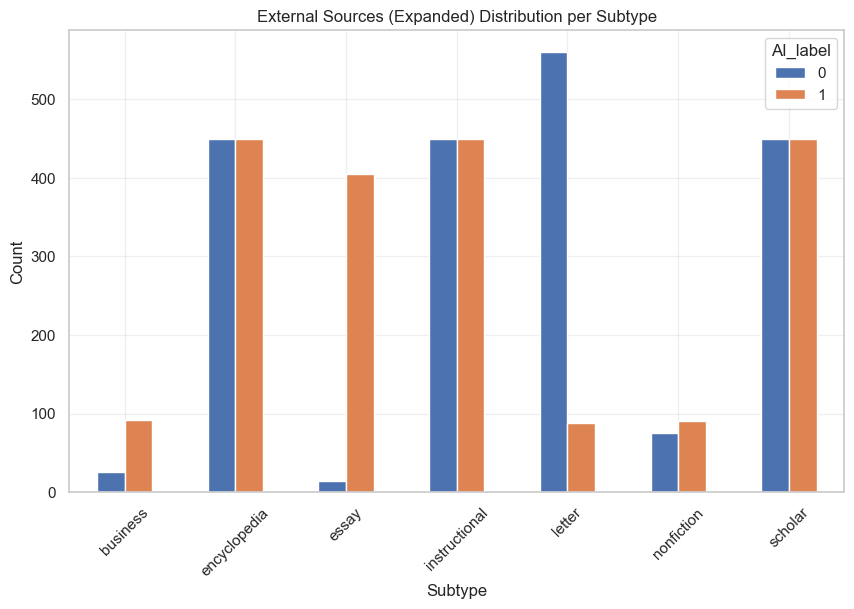

In [91]:
subtype_counts = external_eval_expanded_df.groupby("sub-type")["AI_label"].value_counts().unstack(fill_value=0)

# visuals (for report)
subtype_counts.plot(kind="bar", figsize=(10,6))
plt.title("External Sources (Expanded) Distribution per Subtype")
plt.xlabel("Subtype")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.savefig(os.path.join(output_dir, "external_expanded_subtypes.png"))
plt.show()

In [85]:
external_test_probs = torch.softmax(
    torch.tensor(preds_output.predictions), dim=-1
).numpy()[:, 1]

external_eval_expanded_class = np.argmax(preds_output.predictions, axis=-1)

external_eval_expanded_df = external_eval_expanded_df.reset_index(drop=True)

external_eval_expanded_df["label"] = preds_output.label_ids
external_eval_expanded_df["pred"] = predicted_classes
external_eval_expanded_df["prob_ai"] = external_eval_expanded_class

,sample_text,sub-type,AI_label,label,pred,prob_ai
0,Even though lots of students like to work at h...,letter,0,0,0,0
1,Fresh air we're use to being home all day and ...,nonfiction,0,0,0,0
2,Many people believe that self-esteem comes fro...,letter,0,0,1,1
3,"Clearly, everyone should always aim high and a...",letter,0,0,1,1
4,I really think that can be really stressed for...,letter,0,0,0,0
...,...,...,...,...,...,...
4045,"Helio Vera (born Helio Andrade; January 1, 195...",encyclopedia,1,1,1,1
4046,The Allied Standards Avionics Architecture Cou...,encyclopedia,1,1,0,0
4047,Valet Girls is a 2019 Indian Hindi-language bi...,encyclopedia,1,1,1,1
4048,Benalto was an Italian record label founded in...,encyclopedia,1,1,1,1


In [86]:
dashboard = []

for subtype, group in external_eval_expanded_df.groupby('sub-type'):
    report = classification_report(
        group['AI_label'], group['pred'], digits=4, output_dict=True
    )

    try:
        auc = roc_auc_score(group['AI_label'], group['prob_ai'])
    except ValueError:
        auc = None

    dashboard.append({
        "subtype": subtype,
        "accuracy": report["accuracy"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "auc": auc,
        "report": report
    })


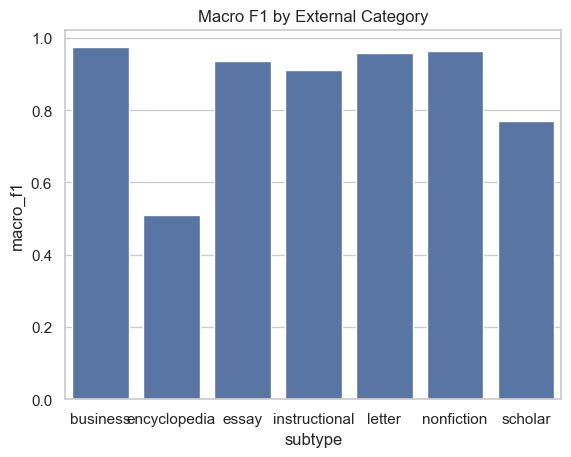

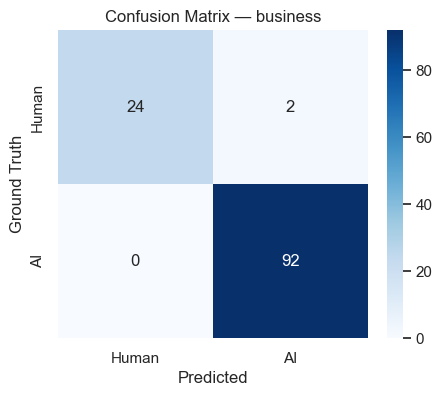

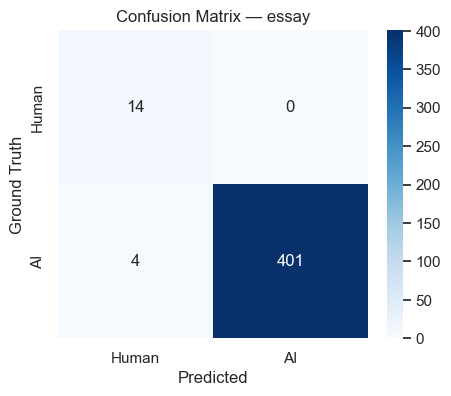

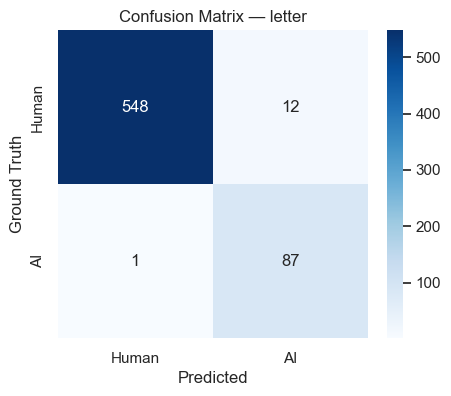

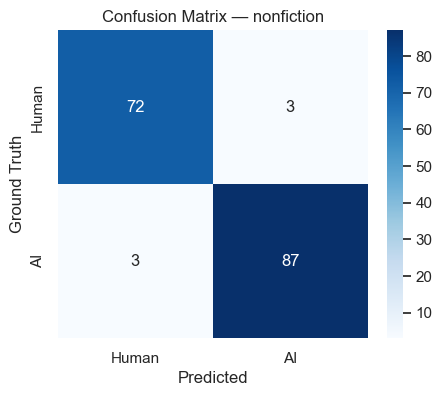

In [92]:
output_dir = './eval_metrics_expanded'

df_dashboard = pd.DataFrame(dashboard)
df_dashboard

sns.barplot(data=df_dashboard, x="subtype", y="macro_f1")
plt.title("Macro F1 by External Category")
plt.savefig(os.path.join(output_dir, "macro_f1_by_subtype.png"))
plt.show()

for subtype, group in external_eval_df.groupby('sub-type'):
    y_true = group['AI_label']
    y_pred = group['pred']

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Human', 'AI'],
                yticklabels=['Human', 'AI'])
    plt.title(f'Confusion Matrix — {subtype}')
    plt.xlabel('Predicted')
    plt.ylabel('Ground Truth')
    plt.savefig(os.path.join(output_dir, f'{subtype}_confusion_matrix.png'))
    plt.show()
